# House Price Prediction

## Project Overview: 
The data is used from kaggle. It shows the house prices along with 80 different
columns/features and 1460 records in total. The target variable is SalePrice.

The goal is to predict the SalePrice of houses using multiple models and evaluation metrics
and reaching a conclusion as to which model is better.

The workflow follows a standard ML pipeline:
- Exploratory Data Analysis (EDA)
- Data Cleaning and Handling Missing Values  
- Feature Encoding using One Hot Encoding
- Model Building — Linear Regression, Random Forest, XGBoost
- Model Evaluation using MAE, RMSE, and R2 Score



### Importing the data

In [1]:
import pandas as pd
data = pd.read_csv("C:/Users/Ayman/Desktop/G/Lock_in_period/train (1).csv")

print(data.head())
print(data.shape)

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

In [2]:
print(data.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


### Getting all the columns with Null values

In [3]:
null_count = data.isnull().sum()
print(null_count[null_count>0].sort_values(ascending=False))

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64


## Data Cleaning

The columns PoolQC,MiscFeature,Alley,Fence,MasVnrType contains a significant amount of null values
so as these are large in numbers and these columns seems to be of less use, we simply drop these from
our dataset.

For all the garage related columns we notice that all those columns have exactly 81 null values,
which indicate that those might be the houses with no garage.So to deal with this we replace the categorical
null values with "None" and the numeric one with 0. And we follow the same with Basement related columns
using the same logic for it. Again same exact logic for the column FireplaceQu which has 690 nulls, 
those might be houses with no fireplace hence we replace it by "None".

For the LotFrontage column with 259 nulls, we use group imputation method to fill the null values,
using the median values of LotFrontage with respect to the neighbourhood.

And lastly, the columns with 8 nulls and 1 null we simply drop those records.



In [4]:
cols_drop = ["PoolQC","MiscFeature","Alley","Fence","MasVnrType"]
data = data.drop(columns = cols_drop, axis=1) #dropping columns

In [5]:
cols_to_fill = ["GarageType","GarageFinish","GarageQual","GarageCond","FireplaceQu",
                "BsmtFinType1","BsmtFinType2","BsmtExposure","BsmtCond","BsmtQual"]

data[cols_to_fill] = data[cols_to_fill].fillna("None") #filling nulls/empty values

In [6]:
data["GarageYrBlt"] = data["GarageYrBlt"].fillna(0) #filling null

So for the LotFrontage we use group based imputation technique used below.

In [7]:
data["LotFrontage"] = data["LotFrontage"].fillna(data.groupby("Neighborhood")["LotFrontage"].transform("median"))

In [8]:
data = data.dropna(subset=["MasVnrArea","Electrical"])

In [9]:
print(data.isnull().sum())

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 76, dtype: int64


In [10]:
data.isnull().sum().sum() #Confirming no nulls.

np.int64(0)

In [11]:
data.shape

(1451, 76)

# Visuals

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

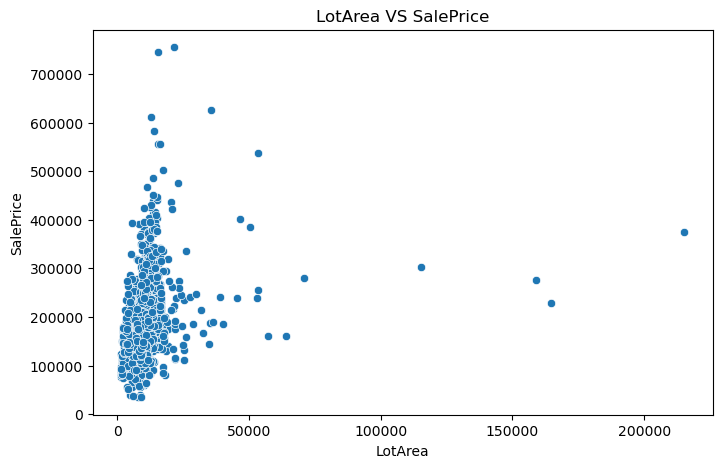

In [13]:
#Lotarea VS SalePrice

plt.figure(figsize = (8,5))
sns.scatterplot(x="LotArea",y="SalePrice",data=data)
plt.title("LotArea VS SalePrice")
plt.show()

From the above chart it is clear that LotArea is weak predictor standalone. Most properties with smaller 
lot areas have a similar but varying prices. Extreme outliers with larger lot areas do not gurantee
higher sale price indicating skewness.

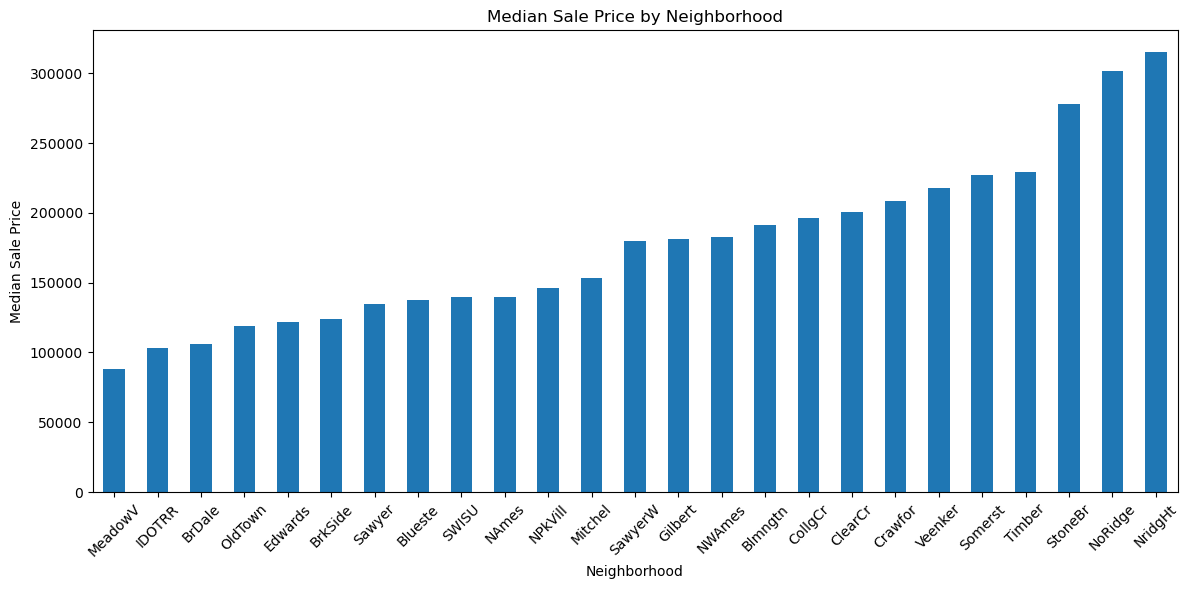

In [14]:
#Neighborhood VS SalePrice

plt.figure(figsize=(14,6))
data.groupby('Neighborhood')['SalePrice'].median().sort_values().plot(kind='bar')
plt.title('Median Sale Price by Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Median Sale Price')
plt.xticks(rotation=45)
plt.show()

From the above graph we can observe the following:
- Neighborhood is a strong predictor of SalePrice.
- Clear price tiers exist — NridgHt, NoRidge, StoneBr are premium
- neighborhoods while MeadowV, IDOTRR, BrDale are low price areas.
- Neighborhoods can be binned into Low/Medium/High price tiers
- as a feature engineering opportunity to improve model performance.

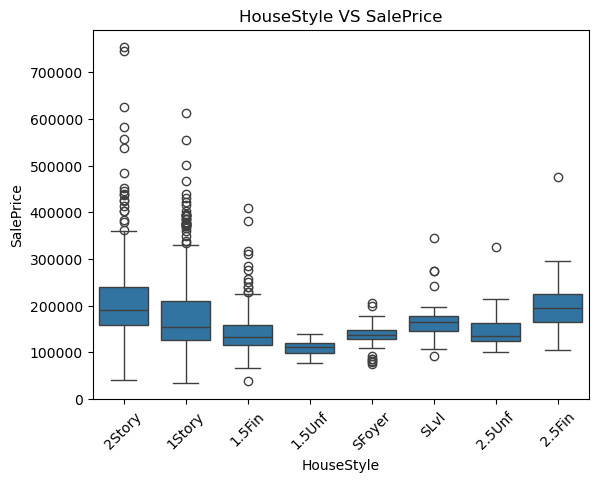

In [15]:
#HouseStyle VS SalePrice

sns.boxplot(x="HouseStyle",y="SalePrice",data=data)
plt.title("HouseStyle VS SalePrice")
plt.xticks(rotation=45)
plt.show()

Insights from the above graph:
- HouseStyle is a moderate predictor of SalePrice.
- Fully completed 2-Story houses command the highest median prices.
- Unfinished homes (1.5Unf, SFoyer) have the lowest prices.
- Completion level and number of floors directly influence sale price.

Since we have a lot of categorical data in our dataset we need it to be numeric, but 
Label Encoding will do it in a way that it gets an unnecessary order. Hence to deal with 
it we use One Hot Encoding. It creates separate binary columns for each category.

In [16]:
data = pd.get_dummies(data,drop_first=True)
data.shape

(1451, 245)

# Modelling

## Random Forest :

In [17]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

X = data.drop("SalePrice",axis=1)
Y = data["SalePrice"]

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)

rf_model = RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train,Y_train)

Y_pred = rf_model.predict(X_test)

print("Mean Absolute error :", mean_absolute_error(Y_pred,Y_test))
print("Root Mean Squared error :", np.sqrt(mean_squared_error(Y_pred,Y_test)))
print("r2_score :", r2_score(Y_pred,Y_test))

(1160, 244)
(291, 244)
Mean Absolute error : 14725.783402061856
Root Mean Squared error : 21631.116222800447
r2_score : 0.9015089619530952


### Results of Random Forest :
The Random Forest model achieved a strong performance with an R² score of 0.90, indicating that it explains around 90% of the variance in house prices. The Mean Absolute Error (MAE) of approximately 14,726 suggests that, on average, the model’s predictions deviate from actual prices by this amount, while the Root Mean Squared Error (RMSE) of 21,631 indicates the presence of some larger prediction errors. Overall, the model performs well, but the higher RMSE compared to MAE suggests that it may struggle with accurately predicting extreme values or outliers.

## Linear Regression :

In [18]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train,Y_train)

Y_pred = lr_model.predict(X_test)
print("Mean Absolute error :", mean_absolute_error(Y_pred,Y_test))
print("Root Mean Squared error :", np.sqrt(mean_squared_error(Y_pred,Y_test)))
print("r2_score :", r2_score(Y_pred,Y_test))

Mean Absolute error : 18666.006436428597
Root Mean Squared error : 51277.80820458604
r2_score : 0.6452632576344914


### Results of Linear Regression :
The Linear Regression model achieved an R² score of 0.65, indicating a moderate fit and significantly lower explanatory power compared to the Random Forest model. The Mean Absolute Error (MAE) of approximately 18,666 shows higher average prediction error, while the Root Mean Squared Error (RMSE) of 51,278 is substantially larger, suggesting the presence of significant prediction errors and poor handling of outliers. Overall, the model underperforms and is less reliable for accurate house price prediction, likely due to its inability to capture complex non-linear relationships in the data.

## XGBoost :

In [19]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators = 100,random_state=42)
xgb_model.fit(X_train,Y_train)

Y_pred = xgb_model.predict(X_test)

print("Mean Absolute error :", mean_absolute_error(Y_pred,Y_test))
print("Root Mean Squared error :", np.sqrt(mean_squared_error(Y_pred,Y_test)))
print("r2_score :", r2_score(Y_pred,Y_test))

Mean Absolute error : 15578.873046875
Root Mean Squared error : 22103.625765923563
r2_score : 0.8983776569366455


### Results of XGBoost :
The XGBoost model achieved an R² score of 0.898, indicating strong predictive performance and explaining nearly 90% of the variance in house prices. The Mean Absolute Error (MAE) of approximately 15,579 suggests relatively accurate average predictions, while the Root Mean Squared Error (RMSE) of 22,104 indicates the presence of some larger errors. Overall, the model performs well and is comparable to the Random Forest model, though it does not show a significant improvement in prediction accuracy.

# Overall Model Comparison and conclusion :

| Model              | MAE   | RMSE  | R²    |
|--------------------|-------|-------|-------|
| Linear Regression  | 18.6K | 51.2K | 0.65  |
| Random Forest      | 14.7K | 21.6K | 0.90  |
| XGBoost            | 15.6K | 22.1K | 0.898 |

Random Forest and XGBoost both perform strongly, but Random Forest slightly outperforms XGBoost in terms of lower error and higher R², while Linear Regression significantly underperforms due to its inability to capture non-linear relationships.

Additionally, we are aware that XGBoost is a superior and advance model and still it did not outperform
Random Forest model. This can be related to the relatively small dataset, and also lack of hyperparameter tuning
of XGBoost. However, on the other hand Random Forest is a more stable and robust model with default parameters,
hence was able to give better output.

In [20]:
import pandas as pd

feature_importance = pd.Series(rf_model.feature_importances_,index = X.columns).sort_values(ascending=False)[:15]

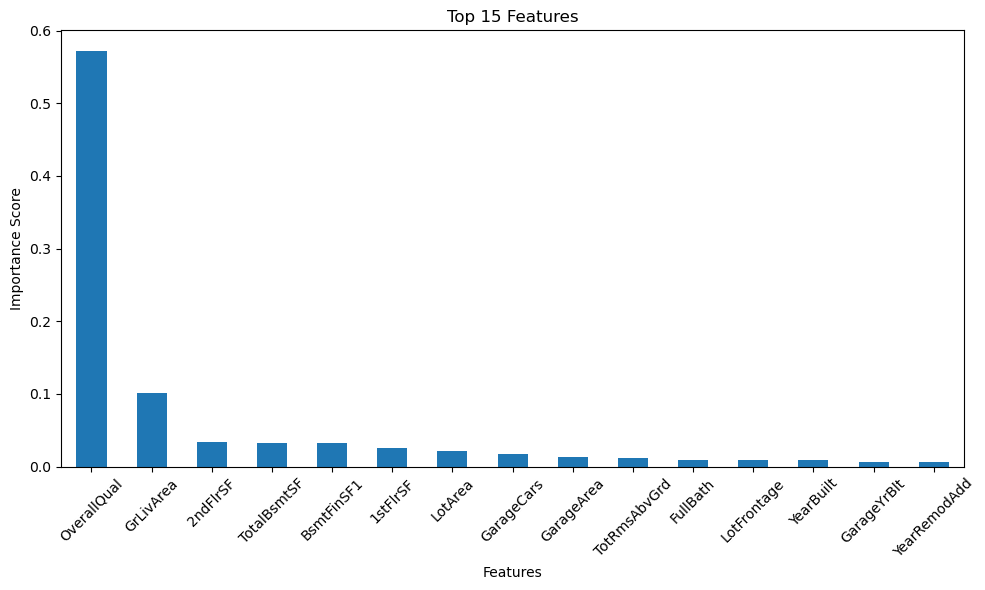

In [21]:
plt.figure(figsize=(10,6))
feature_importance.plot(kind="bar")
plt.title("Top 15 Features")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Insights from the above graph :
- OverallQual is by far the strongest predictor at 0.57 importance.
- Quality of the house matters more than size, location or any other feature.
- GrLivArea (living area size) is second most important at 0.10.
- Neighborhood doesn't appear because One Hot Encoding split it into 25 columns, diluting its individual importance scores.

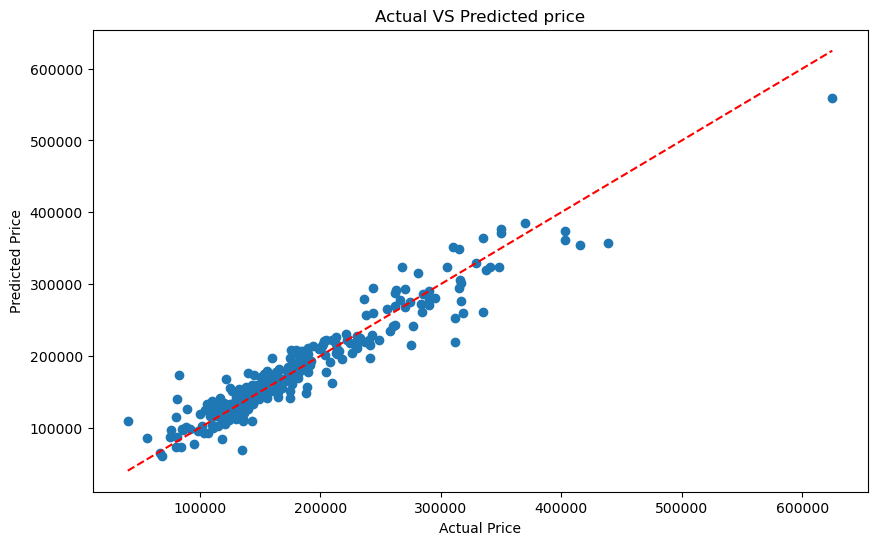

In [22]:
#Actual VS Predicted

plt.figure(figsize=(10,6))
plt.scatter(Y_test,Y_pred)
plt.plot([Y_test.min(),Y_test.max()],[Y_test.min(),Y_test.max()],"r--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual VS Predicted price")
plt.show()

## Insights from the above graph :
Model performs well for mid range houses but struggles with high value properties.
Prediction deviates as price increases. When I read about this, it is known as
Heteroscedasticity. Log Transformation of SalePrice could possibly reduce this variance.

# Cross Validation :

In [25]:
from sklearn.model_selection import cross_val_score

scores_lr = cross_val_score(lr_model,X,Y,cv=5,scoring="r2")
print("LR Individual fold scores :",scores_lr)
print("LR mean r2Score :",scores_lr.mean())
print("LR standard deviation :",scores_lr.std())

LR Individual fold scores : [0.09602709 0.82479362 0.81425055 0.8906917  0.65053069]
LR mean accuracy : 0.6552587321807446
LR standard deviation : 0.2905895867687258


### Results of Cross validation (Linear regression) :
The mean CV r2Score and the single split r2Score was almost same (0.65). Indicating same explanatory power
in both cases.

In [28]:
scores_rf = cross_val_score(rf_model,X,Y,cv=5,scoring="r2")
print("RF Individual fold scores :",scores_rf)
print("RF mean r2Score :",scores_rf.mean())
print("RF standard deviation :",scores_rf.std())

RF Individual fold scores : [0.87118647 0.83518097 0.87763362 0.8757643  0.81582111]
RF mean r2Score : 0.8551172951736199
RF standard deviation : 0.025032576928215297


### Results of Cross validation (Random Forest) :
Here the mean CV r2Score was 0.85 which lower compared to single split r2Score (0.90) with
a standard deviation of 2.5%. Meaning, the single split test happened to get a relatively easy test set.

In [29]:
scores_xgb = cross_val_score(xgb_model,X,Y,cv=5,scoring="r2")
print("XGB Individual fold scores :",scores_xgb)
print("XGB mean r2Score :",scores_xgb.mean())
print("XGB standard deviation :",scores_xgb.std())

XGB Individual fold scores : [0.86810952 0.83759367 0.87523419 0.89790875 0.84934878]
XGB mean r2Score : 0.8656389832496643
XGB standard deviation : 0.020935229200061956


### Results of Cross validation (XGBoost) :
The mean CV r2Score (0.86) was slightly lower than the single split r2Score (0.89) with 
standard deviation of 2%. Meaning, the single split got a relatively easy test set.


Overall, we observe that R2 scores obtained using CV are better for XGBoost
when compared to Random forest contradicting the fact that Random forest had 
a better score in single split scenario. Hence we conclude that CV shows
us the bigger and true picture about the dataset and is considered to be more reliable.

## Future Imporvements :
- LogTransformation of SalePrice to reduce variance.
- Hyperparameter tuning for XGBoost
- Binning the Neighborhood into price tiers.